## Spike threshold detector and time stamp generator (6,+) 

The task is to write a program which detects spikes within a noisy baseline. 

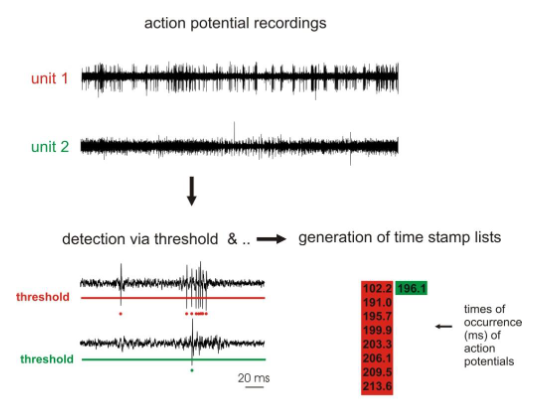

### Details: 

- The program should expect at least three inputs: the raw data (e.g. electrophysiological recordings), the sampling interval (in ms or μs) and the threshold(s). Each column of the raw data represents one channel (time going down the columns). In other words, the function must be able to deal with multi-channel (=multi-column) data 

- The program must output the occurrences of action potentials in msfor each channel in the form of a 'time stamp list' (`tsl`), that is, a column array containing the occurrences. The tsl of the different channels should be placed into a suitable data structure.

- A spike's time stampshould be defined as the first datapoint above (or below) threshold •the program must be able to detect, for each channel, positive-going or negative-going spikes (not both at the same time! One threshold per channel suffices, otherwise things get too complicated). The program should infer the direction of the spikes it should detect in a given channel from the sign of the threshold (so, negative threshold means look for negative-going spikes, positive threshold means look for positive-going spikes). 

- Data provided for this project are in the sub folder `spike_threshold`. Note that `rawdata01.mat` is a Matlab file; there are several possibilities to import `.mat`. files into Python. The file contains two variables, `d` and `si`. `d` is the raw data; each column corresponds to one channel. Note that the data type of `d` is single. `si` is the sampling interval in μs.



## PART1: Import Data & Define Data 

In [1]:
# Import the loadmat function, which lets Python open .mat files
from scipy.io import loadmat  

# Load the .mat file. This reads everything stored inside the file and puts it into a Python dictionary-like object called "data".
data = loadmat('/home/jovyan/work/__shared/exam_projects/spike_threshold/rawdata01.mat')

# Pull 'd' out of the dictionary.
d = data['d']

# Pull out 'si' and call .item() to "unwrap" it and get a plain Python number (99) instead of a matrix.
si = data['si'].item()

# Print d's shape and si's value, as a quick sanity check that the data loaded correctly.
print(d.shape, si)

(1010101, 2) 99


## PART2:To Visualize the Raw Data

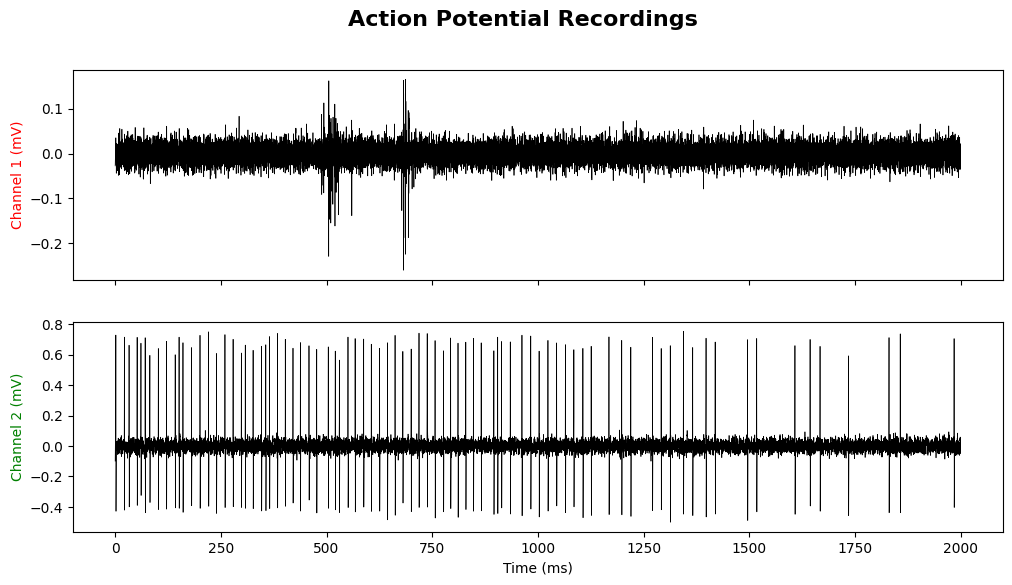

In [2]:
 # NumPy: lets us do fast math on whole arrays of numbers at once
 # Matplotlib: the plotting library used to draw the figures
import numpy as np              
import matplotlib.pyplot as plt 

# Convert the sampling interval from microseconds to milliseconds (divide by 1000)
si_ms = si / 1000

# Build a time axis so we can plot the data against real time instead of sample number
time = np.arange(d.shape[0]) * si_ms

# Create a figure with 2 rows and 1 column of subplots - one plot per recording channel
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Mask for first 2 seconds = 2000 ms
mask = time < 2000

# Give the whole figure a title (sits above both subplots).
fig.suptitle('Action Potential Recordings', fontsize=16, fontweight='bold')

# Channel 1 (top subplot) 
axes[0].plot(time[mask], d[mask, 0], lw=0.5, color='black')
axes[0].set_ylabel('Channel 1 (mV)', color='red')  # label the y-axis for channel 1

# Channel 2 (bottom subplot)
axes[1].plot(time[mask], d[mask, 1], lw=0.5, color='black')
axes[1].set_ylabel('Channel 2 (mV)', color='green')  # label the y-axis for channel 2

# The two subplots share an x-axis, so we only need to label it once, on the bottom plot.
axes[1].set_xlabel('Time (ms)', color='black')

plt.show()          

### PART2: AI Revised Version By Claude 

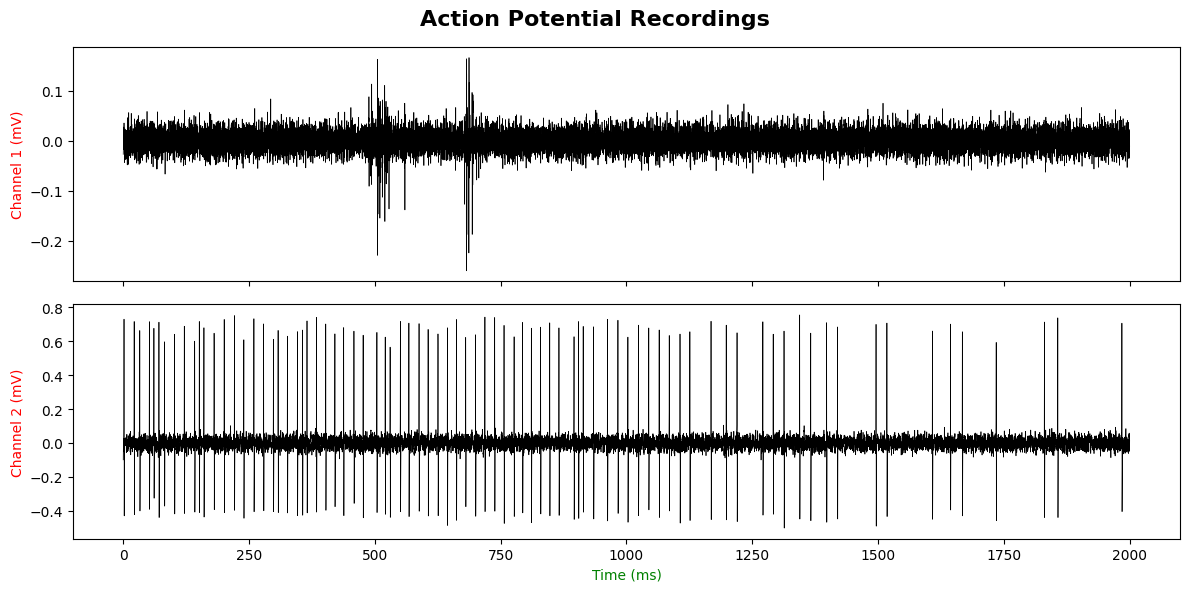

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Settings 
si_ms = si / 1000              # sampling interval, converted from microseconds to milliseconds
max_time_ms = 2000              # only plot the first 2000 ms of the recording
n_channels = d.shape[1]         # number of channels in the data

# Build the time axis and a mask for the time window we want to show 
t = np.arange(d.shape[0]) * si_ms
mask = t < max_time_ms

# Plot 
fig, axes = plt.subplots(n_channels, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Action Potential Recordings', fontsize=16, fontweight='bold')

for ch in range(n_channels):
    axes[ch].plot(t[mask], d[mask, ch], lw=0.5, color='black')
    axes[ch].set_ylabel(f'Channel {ch + 1} (mV)', color='red')  

axes[-1].set_xlabel('Time (ms)', color='green')
plt.tight_layout()
plt.show()

## PART3: Threshold Calculation

In [4]:
def auto_threshold(x, k=4):
    '''
    Automatically figure out a good threshold for spike detection, and decide whether it is a positive-going or negative-going spikes.
    x: the signal for one channel
    k: how many "noise units" away from the middle counts as a spike
    '''

    # Find the median (the "middle" value) of the signal.
    median = np.median(x)

    # Measure how far every single data point is from that median. 
    distance_from_median = np.abs(x - median)

    # MAD = Median Absolute Deviation. Taking the median of those distances gives a robust estimate of the signal's "noise level".
    mad = np.median(distance_from_median)

    # Convert MAD into an estimate of the noise's standard deviation. 
    noise = mad / 0.6745

    # Define two thresholds: one above the baseline (catches upward/positive spikes)and one below the baseline (catches downward/negative spikes). 
    # k controls how many noise units away from baseline we require before calling something a spike.
    pos_thr = median + k * noise
    neg_thr = median - k * noise

    # Count how many data points actually cross each threshold.
    n_pos_thr = np.sum(x > pos_thr)
    n_neg_thr = np.sum(x < neg_thr)

    # Whichever threshold catches more crossings tells us which direction the real spikes go in this channel, so we return that one as the threshold to use going forward.
    if n_neg_thr > n_pos_thr:
        return neg_thr
    else:
        return pos_thr

### MAD Citation: 
“The thresholds achieving the maximum number of reasonable detection results are seen to be optimal and have been used in the rest experiments which are: EC–PC = 0.8, CWD = −0.1,AT = 3.5×RMS, MAD = 4×STD, NEO = 10.” (Zhou et al., 2014)

Zhou, Y., Wu, T., Rastegarnia, A., Guan, C., Keefer, E., & Yang, Z. (2014). On the robustness of EC–PC spike detection method for online neural recording. Journal of Neuroscience Methods, 235, 316–330. https://doi.org/10.1016/j.jneumeth.2014.07.006 

## PART4: Threshold Detection

In [5]:
def spike_detect(d, si, k=4):
    '''
    Detect spikes in multi-channel data. Thresholds are calculated automatically for each channel using auto_threshold.

    d : raw data, one column per channel
    si : sampling interval (as stored in the .mat file, in microseconds)
    k : how many 'noise units' away from baseline counts as a spike
    '''

    si_ms = si/1000           # convert the sampling interval to milliseconds, same as before
    n_samples = d.shape[0]    # total number of time samples (rows) in the data
    n_channels = d.shape[1]   # total number of recording channels (columns) in the data

    # Work out one threshold per channel by running auto_threshold() on each column of d,
    # and collect all of them in a list so we can look each one up by channel number later.
    thresholds = []
    for ch in range(n_channels):
        channel_data = d[:, ch]              # grab just this channel's data (one column)
        thr = auto_threshold(channel_data, k)
        thresholds.append(thr)

    print("Auto thresholds:", thresholds)
 
    # "tsl" = time-stamp list. This dictionary will hold, for each channel, the list of times (in ms) at which a spike was detected.
    tsl = {}  
    
    # Loop through the channels one at a time and collect the spike times just for this channel
    for ch in range(n_channels):
        channel_data = d[:, ch]
        thr = thresholds[ch]
        spike_times = []  

        # Walk through the signal one sample at a time (starting at sample 1, so there is
        # always a previous sample to compare against), checking whether the signal has
        # just "crossed" the threshold between the previous sample and the current one.
        for i in range(1, n_samples):
            previous_value = channel_data[i-1]
            current_value = channel_data[i]
    
            # If the threshold is positive, a spike is detected when the signal goes from below the threshold to at/above it (an upward crossing).
            if thr >= 0:
                just_crossed = (previous_value < thr) and (current_value >= thr)
            # If the threshold is negative, a spike is detected when the signal goes from above the threshold to at/below it (a downward crossing).
            else:
                just_crossed = (previous_value > thr) and (current_value <= thr)
            # convert the sample index into an actual time and record this spike's time
            if just_crossed:
                spike_time = i * si_ms          
                spike_times.append(spike_time)  

        tsl[ch] = np.array(spike_times)   # store this channel's spike times as a NumPy array
        print(f"Channel {ch}: {len(spike_times)} spikes detected")

    return tsl, thresholds    # give back both the spike times and the thresholds used

## PART5: Plots for Spike Detection

Auto thresholds: [np.float32(-0.07412898), np.float32(-0.10926757)]
Channel 0: 564 spikes detected
Channel 1: 2386 spikes detected


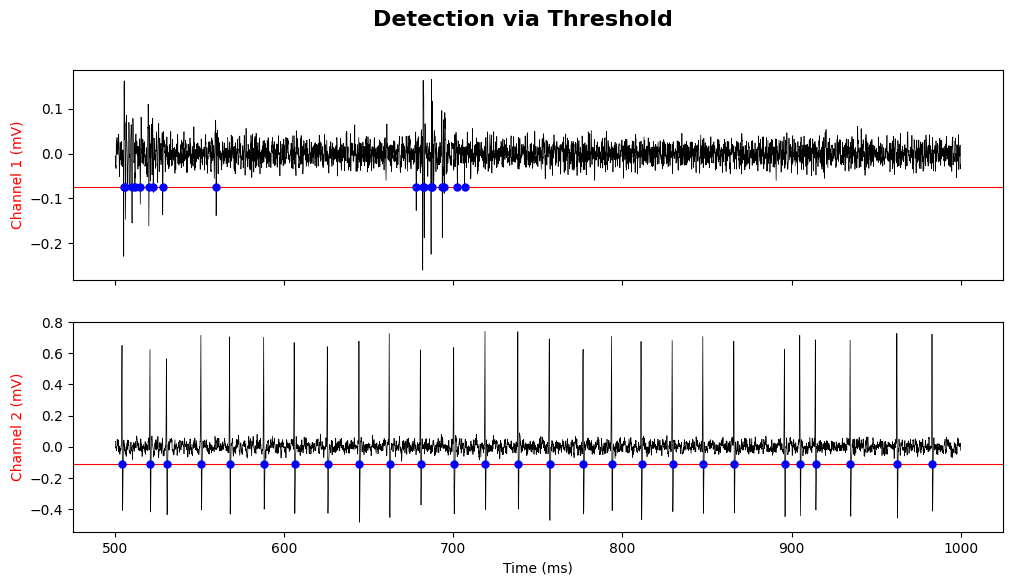

In [6]:
# Run the spike detector on the full dataset. This gives us: tsl and thresholds. 
tsl, thresholds = spike_detect(d, si, k=4)

# Create a new figure.
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Zoom in on a shorter, 500 ms window (from 500 ms to 1000 ms) so individual spikes and threshold crossings are easy to see.
mask = (time > 500) & (time < 1000)
fig.suptitle('Detection via Threshold', fontsize=16, fontweight='bold')

n_channels = d.shape[1]
for ch in range(n_channels):
    # Plot the raw signal for this channel, within the zoomed-in time window.
    axes[ch].plot(time[mask], d[mask, ch], lw=0.5, color='black')

    # Draw a horizontal red line showing exactly where the threshold sits
    axes[ch].axhline(thresholds[ch], color='r', ls='-', lw=0.8)

    # From all the spike times detected for this channel, keep only the ones that fall inside our current 500-1000 ms viewing window.
    times_in_range = tsl[ch][(tsl[ch] > 500) & (tsl[ch] < 1000)]

    # Mark each detected spike with a blue dot, placed right on the threshold line at the exact time it was detected.
    axes[ch].plot(times_in_range, [thresholds[ch]]*len(times_in_range),"bo", ms=5)
    axes[ch].set_ylabel(f'Channel {ch + 1} (mV)', color='red')

axes[-1].set_xlabel('Time (ms)')
plt.show()

## PART6: Time Stamp Generator

In [7]:
# Print out a preview of the detected spike times for each channel
# Only show the first 10 spike times and the total number of spikes found 
for ch, times in tsl.items():
    print(f"Channel {ch + 1} time stamp list (ms)")
    for spike_time in times[:10]:   
        print(f"{spike_time:.1f}")
    print(f"... ({len(times)} total)")  

Channel 1 time stamp list (ms)
488.5
493.4
505.0
506.1
509.9
511.7
514.9
519.9
522.5
528.1
... (564 total)
Channel 2 time stamp list (ms)
1.8
22.0
33.2
52.2
61.2
71.2
82.3
102.3
121.7
142.3
... (2386 total)


### PART6: AI Revised Version By Claude

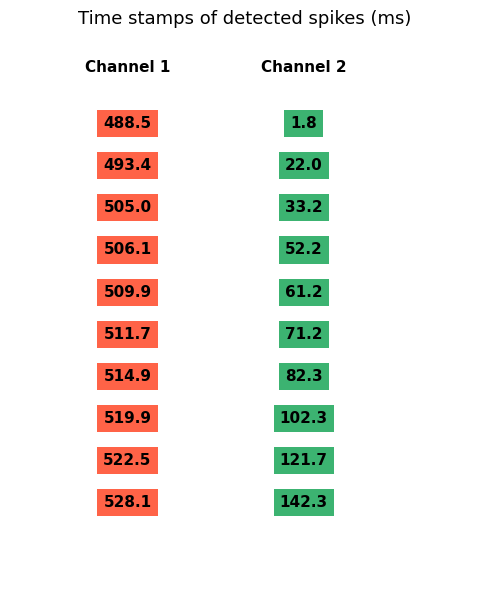

In [8]:
import matplotlib.pyplot as plt

n_channels = len(tsl)
n_show = 10  

colors = ['tomato', 'mediumseagreen', 'cornflowerblue', 'gold']

fig, ax = plt.subplots(figsize=(2.5 * n_channels, 6))
ax.axis('off')  

for ch, times in tsl.items():

    color = colors[ch % len(colors)]

    x_pos = ch * 1.2

    for i, spike_time in enumerate(times[:n_show]):

        y_pos = -i * 0.6

        ax.text(
            x_pos, y_pos,
            f'{spike_time:.1f}',
            va='center',
            ha='center',
            fontsize=11,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor=color, edgecolor='none', boxstyle='square,pad=0.4')
        )

    ax.text(
        x_pos, 0.8,
        f'Channel {ch + 1}',
        va='center',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.set_xlim(-0.8, n_channels * 1.2)
ax.set_ylim(-n_show * 0.6 - 0.5, 1.3)

ax.set_title('Time stamps of detected spikes (ms)', fontsize=13)
plt.tight_layout()
plt.show()